# Factor Lab — 交互式因子挖掘

## 使用流程

1. 修改 `SYMBOL` 和 `CONFIG` 指向目标品种和配置文件
2. 运行 **Cell 1**（初始化，只需一次，约 10~30 秒）
3. 在**因子设计区**编写 `my_factor` 函数
4. 依次运行 **因子诊断 / IC 分析 / OLS 分析 / 分位分析** Cell，查看结果
5. 修改因子后，只需重新运行步骤 3~4，无需重新初始化

## 分析方法概览

| 方法 | 函数 | 核心指标 | 用途 |
|------|------|---------|------|
| **因子诊断** | `lab.properties_only()` | ACF(1)、半衰期、JB p、ADF/KPSS | 刻画因子自身的自相关结构、分布形态和平稳性，指导预处理策略 |
| **IC 分析** | `lab.ic_only()` | ICIR、t_stat、p_value、win_rate | 验证因子与未来收益的线性相关性，判断方向和显著性 |
| **OLS 分析** | `lab.ols_only()` | beta_mean、t_stat、r2_mean | 量化因子每单位标准差对应的预期收益，与 IC 互相印证 |
| **分位分析** | `lab.quantile_only()` | monotone_r、ls_spread | 检验因子分层收益单调性，识别时段效应 |
| **Horizon 分析** | `lab.horizon_only()` | 各层均值bp、多空价差 | 因子预测力随持仓期的演化 |
| **单因子回测** | `lab.backtest_only()` | Sharpe / 最大回撤 / 胜率 | 持仓状态机净值曲线，含/不含成本双轨对比 |
| **累计收益曲线** | `lab.cumreturn_only()` | 单利累计bp、逐年贡献 | 因子在不同年份的预测能力变化 |

## 数据隔离

`lab.bars` 中的数据严格不包含 `train_end_year` 之后的数据，所有分析结果均基于样本内数据。

## 其他功能（参见文末说明）

- `lab.check_leakage()`：数据泄漏检测
- 多品种对比：循环初始化多个 `FactorLab` 实例

In [1]:
# ── Cell 1：初始化（只需运行一次）────────────────────────────────
import sys
sys.path.insert(0, '.')   # 确保可以 import feature_mining 模块

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from factor_analysis import FactorLab

SYMBOL = 'SHFE_au'      # 修改为目标品种
CONFIG = 'config.json' \
'' \
''  # 修改为配置文件路径

lab = FactorLab(SYMBOL, config_path=CONFIG)

加载缓存数据: KQ_m_SHFE_au_1m_2021-01-01_2025-12-31.parquet
FactorLab 基础设施初始化（轻量模式，跳过特征计算）...
  完成：132,354 行，时间范围 2021-01-04 09:00:00 ~ 2025-12-31 14:55:00

FactorLab 初始化完成
  品种         : SHFE_au
  bars['5m']   : 105,777 行（含预热区，year <= 2024）
  分析样本     : year in [2022, 2024]
  tick_size    : 0.02
  label_bars   : 6 根（30 分钟）
  session_template: night_0230


In [2]:
# ── Cell 2：查看可用数据（可选）──────────────────────────────────
bar5m = lab.bars['5m']
print(f'bars["5m"] 行数 : {len(bar5m):,}')
print(f'时间范围       : {bar5m["datetime"].min()} ~ {bar5m["datetime"].max()}')
print(f'列名           : {bar5m.columns}')
bar5m.head(3)

bars["5m"] 行数 : 105,777
时间范围       : 2021-01-04 09:00:00 ~ 2024-12-31 14:55:00
列名           : ['trading_date', 'datetime', 'datetime_nano', 'open', 'high', 'low', 'close', 'volume', 'open_oi', 'close_oi', 'bar_end_ts', 'continuous_session_id', 'cum_price_gap', 'bar_idx_in_session']


trading_date,datetime,datetime_nano,open,high,low,close,volume,open_oi,close_oi,bar_end_ts,continuous_session_id,cum_price_gap,bar_idx_in_session
date,datetime[ns],i64,f64,f64,f64,f64,i64,i64,i64,i64,i32,f64,i64
2021-01-04,2021-01-04 09:00:00,1609722000000000000,399.36,400.26,398.9,399.8,4955,37201,37749,1609722300000000000,0,0.0,1
2021-01-04,2021-01-04 09:05:00,1609722300000000000,399.8,400.44,399.8,400.28,3548,37749,38137,1609722600000000000,0,0.0,2
2021-01-04,2021-01-04 09:10:00,1609722600000000000,400.28,400.54,400.08,400.46,3097,38137,38755,1609722900000000000,0,0.0,3


---
## 因子设计区

在下方 Cell 中编写 `factor_func`，然后运行对应的评估 Cell。

In [3]:
# ── Cell 3：因子定义 ─────────────────────────────────────────────
def my_factor(bars: dict) -> pl.Series:
    """
    示例：session 内去跳空 20 棒移动平均偏离度
    (shifted_close - MA20) / MA20，反映短期价格位置

    注意：涉及 .over() 的计算必须在 with_columns 中用 pl.Expr 完成，
          不能对 pl.Series 直接调用 .over()。
    """
    bar5m = bars['5m']

    result = (
        bar5m
        # Step 1：计算去跳空收盘价（纯列运算，不需要 .over()）
        .with_columns(
            (pl.col('close') - pl.col('cum_price_gap')).alias('_sc')
        )
        # Step 2：session 内 rolling mean（需要 .over()，必须在 with_columns 里）
        .with_columns(
            pl.col('_sc').rolling_mean(20)
              #.over('continuous_session_id')
              .alias('_ma20')
        )
        # Step 3：计算偏离度
        .with_columns(
            ((pl.col('_sc') - pl.col('_ma20')) / (pl.col('_ma20') + pl.col('cum_price_gap') + 1e-9))
            .alias('ma20_dev')
        )
    )
    return result['ma20_dev']   # 返回 pl.Series，长度 == len(bars['5m'])

---
## IC 分析（`ic_only`）

**方法**：将样本期按交易日序号切分为长度 = `window_days`（默认20个交易日）的**非重叠窗口**，
在每个窗口内计算因子值与未来收益率的 **Pearson IC**（线性相关系数），汇总跨窗口统计量。

收益率列由 `use_ror_norm` 配置控制：
- `true`（默认）：使用 ATR 归一化收益率 `ror_norm_Nb`，跨品种可比
- `false`：使用原始收益率 `ror_future_Nb`

**收益率在计算前会在窗口内做截尾处理**（默认 1%~99%，由 `winsorize_quantiles` 配置），
防止极端行情污染单窗口 IC 估计，同时自适应不同 regime 的收益分布。

**输出指标**：

| 指标 | 含义 | 参考标准 |
|------|------|---------|
| `ic_mean` | 窗口 IC 均值 | >0.02 有参考意义 |
| `icir` | IC均值 / IC标准差 | >0.3 较好 |
| `t_stat` | t 统计量 | 绝对值 >2 视为显著 |
| `p_value` | 双侧 p 值 | <0.05 显著 |
| `win_rate` | IC > 0 的窗口占比 | >55% 方向稳定 |

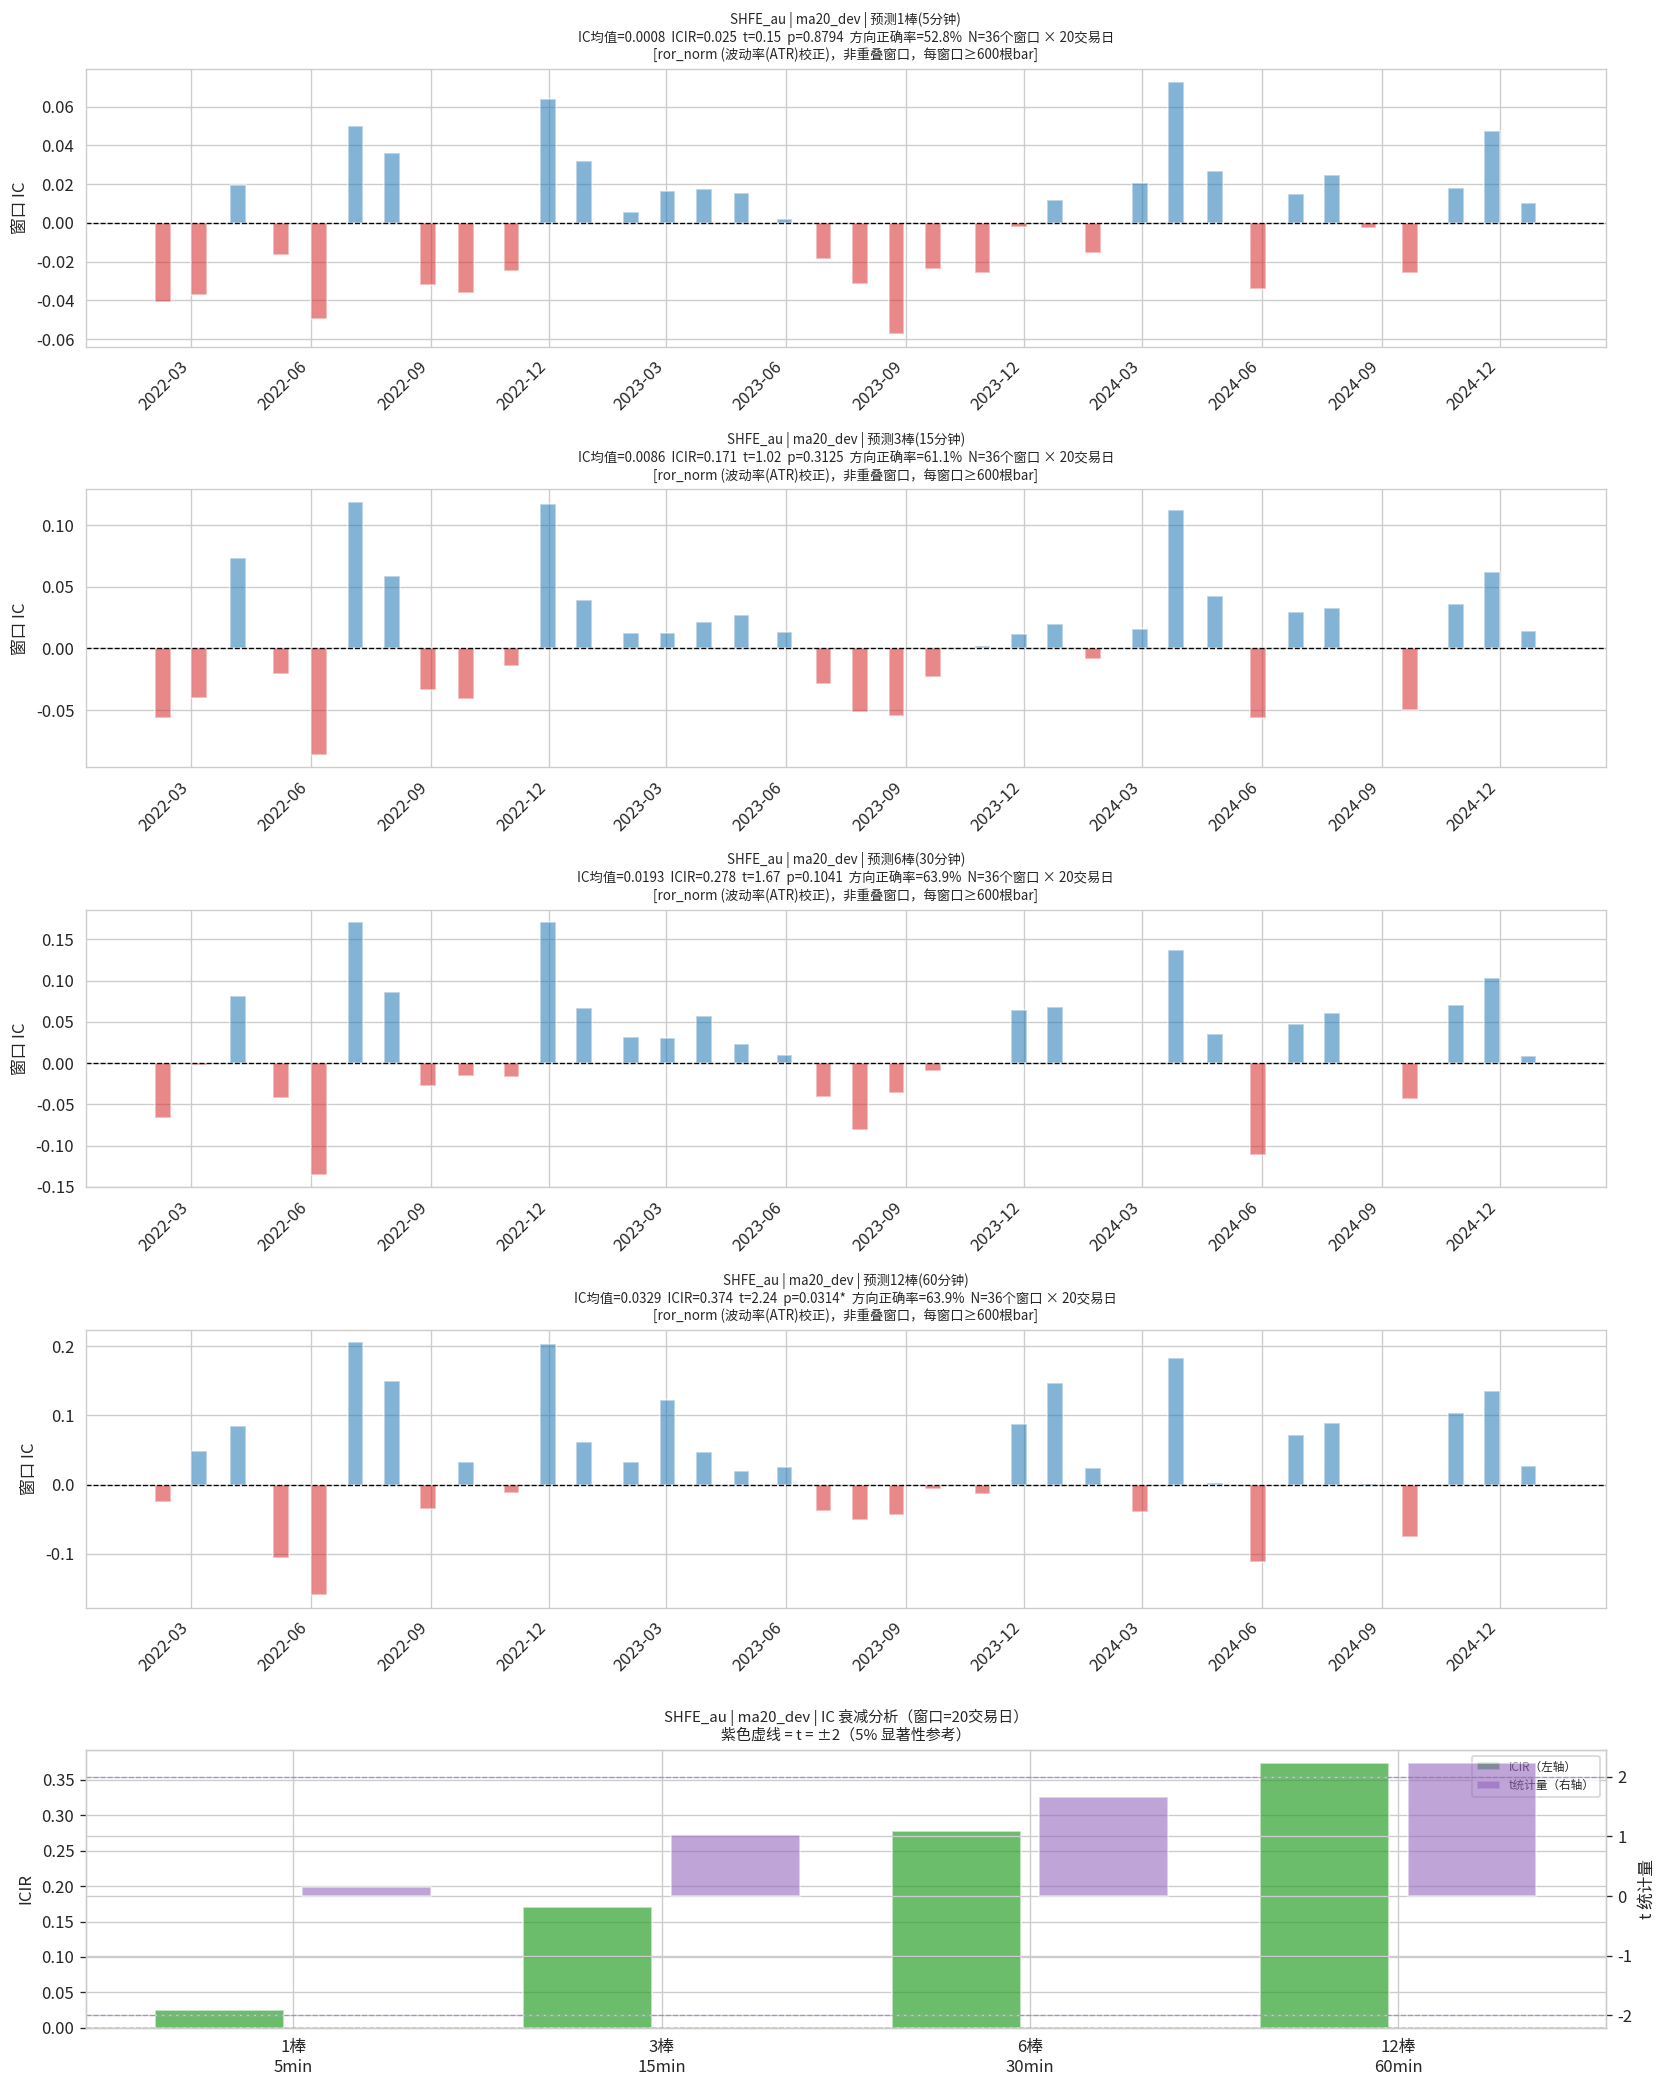

{'factor': 'ma20_dev',
 'period_1_icir': 0.02547010213570336,
 'period_3_icir': 0.17078861399554784,
 'period_6_icir': 0.27815575417293387,
 'period_12_icir': 0.37371107387671515,
 'period_1_ic': 0.000826683111197719,
 'period_3_ic': 0.008581502047694242,
 'period_6_ic': 0.019338540210826052,
 'period_12_ic': 0.032904820332815485,
 'period_1_tstat': np.float64(0.15282061281422016),
 'period_3_tstat': np.float64(1.0247316839732872),
 'period_6_tstat': np.float64(1.668934525037603),
 'period_12_tstat': np.float64(2.242266443260291),
 'period_1_pvalue': 0.8794173793459517,
 'period_3_pvalue': 0.3125204502531389,
 'period_6_pvalue': 0.10405300969937703,
 'period_12_pvalue': 0.03138090904358992,
 'main_ic_mean': 0.019338540210826052,
 'main_icir': 0.27815575417293387,
 'main_t_stat': np.float64(1.668934525037603),
 'main_p_value': 0.10405300969937703,
 'main_win_rate': 0.6388888888888888,
 'main_n_windows': 36}

In [4]:
# ── IC 分析 ───────────────────────────────────────────────────────
ic_stats = lab.ic_only(my_factor, name='ma20_dev')
ic_stats

---
## OLS 分析（`ols_only`）

**方法**：先对因子值做滚动 z-score 标准化（窗口 = `ols_norm_window`，默认200根bar），
再在每个非重叠窗口内对 `ror_norm_Nb ~ z_factor` 做 **OLS 回归**，记录窗口 beta 和 R²。

与 IC 分析的区别：OLS 显式建模线性斜率，beta 的经济含义更直接——
**因子值每增加1个近期标准差，预期未来收益变化 beta**。

逐窗口 OLS 之间相互独立，无需 Newey-West 修正。
收益率同样在窗口内做截尾处理。

**输出指标**：

| 指标 | 含义 | 参考标准 |
|------|------|---------|
| `beta_mean` | 窗口 beta 均值 | 与 IC 方向一致为佳 |
| `t_stat` | beta 序列的 t 统计量 | 绝对值 >2 显著 |
| `r2_mean` | 窗口内平均 R² | 反映线性解释力 |
| `beta_pos_rate` | beta > 0 的窗口占比 | >55% 方向稳定 |

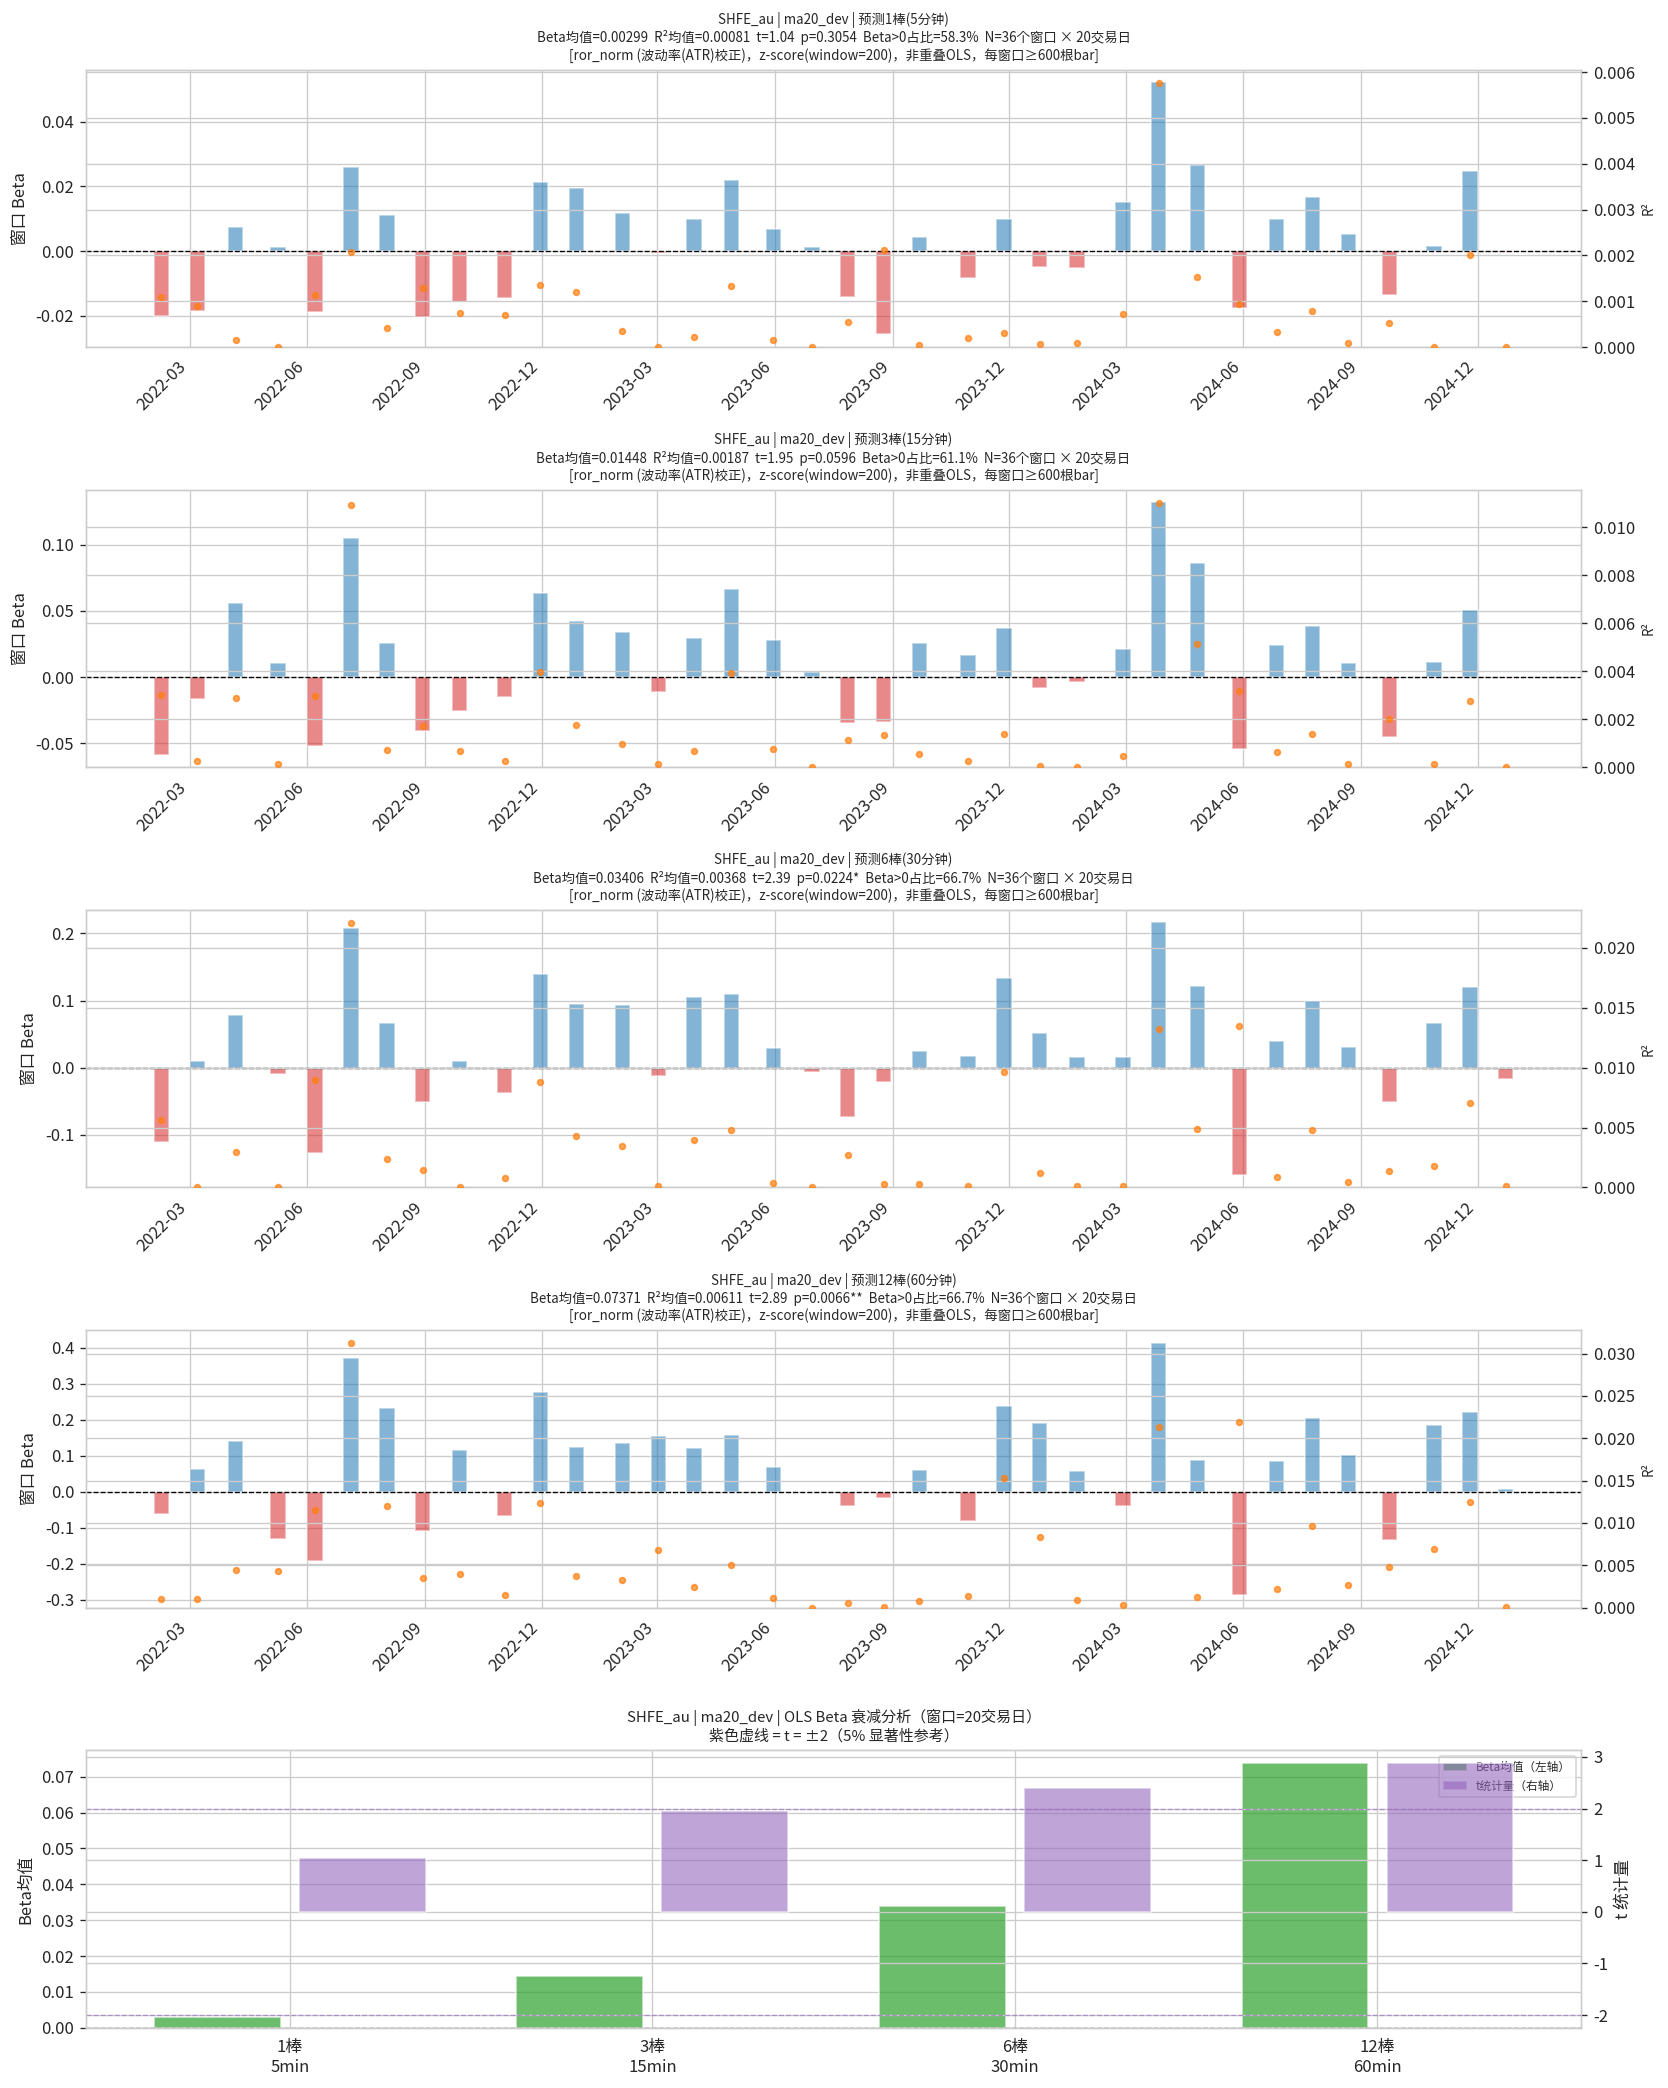

{'factor': 'ma20_dev',
 'period_1_beta': 0.002986714057248371,
 'period_3_beta': 0.014478924552617588,
 'period_6_beta': 0.0340634334608029,
 'period_12_beta': 0.07371138370220802,
 'period_1_r2': 0.0008112562590803353,
 'period_3_r2': 0.0018698623922755082,
 'period_6_r2': 0.003681544429313902,
 'period_12_r2': 0.006107317296171206,
 'period_1_tstat': np.float64(1.040110574235306),
 'period_3_tstat': np.float64(1.9470546660076065),
 'period_6_tstat': np.float64(2.38959943387563),
 'period_12_tstat': np.float64(2.886465918443022),
 'period_1_pvalue': 0.30542061617436356,
 'period_3_pvalue': 0.05958784130668793,
 'period_6_pvalue': 0.022386510795938896,
 'period_12_pvalue': 0.006633326708874732,
 'period_1_beta_posrate': 0.5833333333333334,
 'period_3_beta_posrate': 0.6111111111111112,
 'period_6_beta_posrate': 0.6666666666666666,
 'period_12_beta_posrate': 0.6666666666666666,
 'main_beta': 0.0340634334608029,
 'main_r2': 0.003681544429313902,
 'main_t_stat': np.float64(2.38959943387563

In [5]:
# ── OLS 分析 ──────────────────────────────────────────────────────
ols_stats = lab.ols_only(my_factor, name='ma20_dev')
ols_stats

---
## 因子诊断（`properties_only`）

**方法**：对因子值本身（不依赖收益率）进行三类统计检验，刻画因子的内在性质，
为后续预处理策略和 LightGBM 建模提供依据。建议在 IC/OLS 分析之前先运行。

**三类检验**：

**① 自相关结构**：按 `window_days`（默认20个交易日，约1260根bar/窗口）的**非重叠窗口**分箱，
与 IC/OLS 分析保持完全一致的窗口粒度，确保高阶滞后（如 lag=40）的估计精度。
在每个窗口内计算滞后 1~`max_lags` 棒的 Pearson 自相关，跨窗口取均值（窗口均值 ACF）
和标准差（窗口间 σ），反映 ACF 的 regime 级变化；同时标注全量 ACF 用于对比。
由窗口均值 ACF(1) 估计 AR(1) **半衰期**（因子信号强度衰减到 50% 所需的 bar 数 × 5 = 分钟）。

**② 分布形态**：直方图 + 正态拟合曲线 + Q-Q 图，
标注偏度、超额峰度、Jarque-Bera 正态检验 p 值。

**③ 平稳性**：对每日日内序列分别做 ADF 和 KPSS 检验，跨日取平均 p 值，
给出综合结论；同时绘制逐日均值/标准差时序图和逐年分布稳定性柱状图。

**输出指标**：

| 指标 | 含义 | 参考标准 |
|------|------|----------|
| `acf1_win_mean` | 窗口均值 ACF(lag=1) | 0.3~0.7 正常；< 0.05 近似白噪声 |
| `half_life_bars` | AR(1) 半衰期（bar 数） | 与 `horizon_only` 峰值 horizon 对照 |
| `ess_ratio` | 有效样本比例 ESS/N | 越低说明自相关越强，IC t 检验自由度被高估 |
| `jb_p` | Jarque-Bera 正态检验 p 值 | < 0.05 → 显著非正态，考虑截尾 |
| `stationarity` | ADF + KPSS 综合结论 | 非平稳 → 考虑差分或更大的滚动 z-score 窗口 |

**半衰期与换手率的关系**：半衰期越短，信号切换越频繁，对应更高的模型换手率和交易成本。
建议将 `half_life_bars × 2` 与 `horizon_only` 的 IC 峰值 horizon 对照：
- `half_life × 2` ≈ IC 峰值 horizon → 信号与收益衰减速度匹配，理想状态
- `half_life × 2` ≪ IC 峰值 horizon → 因子信号抖动快，但预测能力持续时间长；
  建议使用较大的滚动 z-score 窗口（≥ `half_life × 10`）稳定信号后再入模

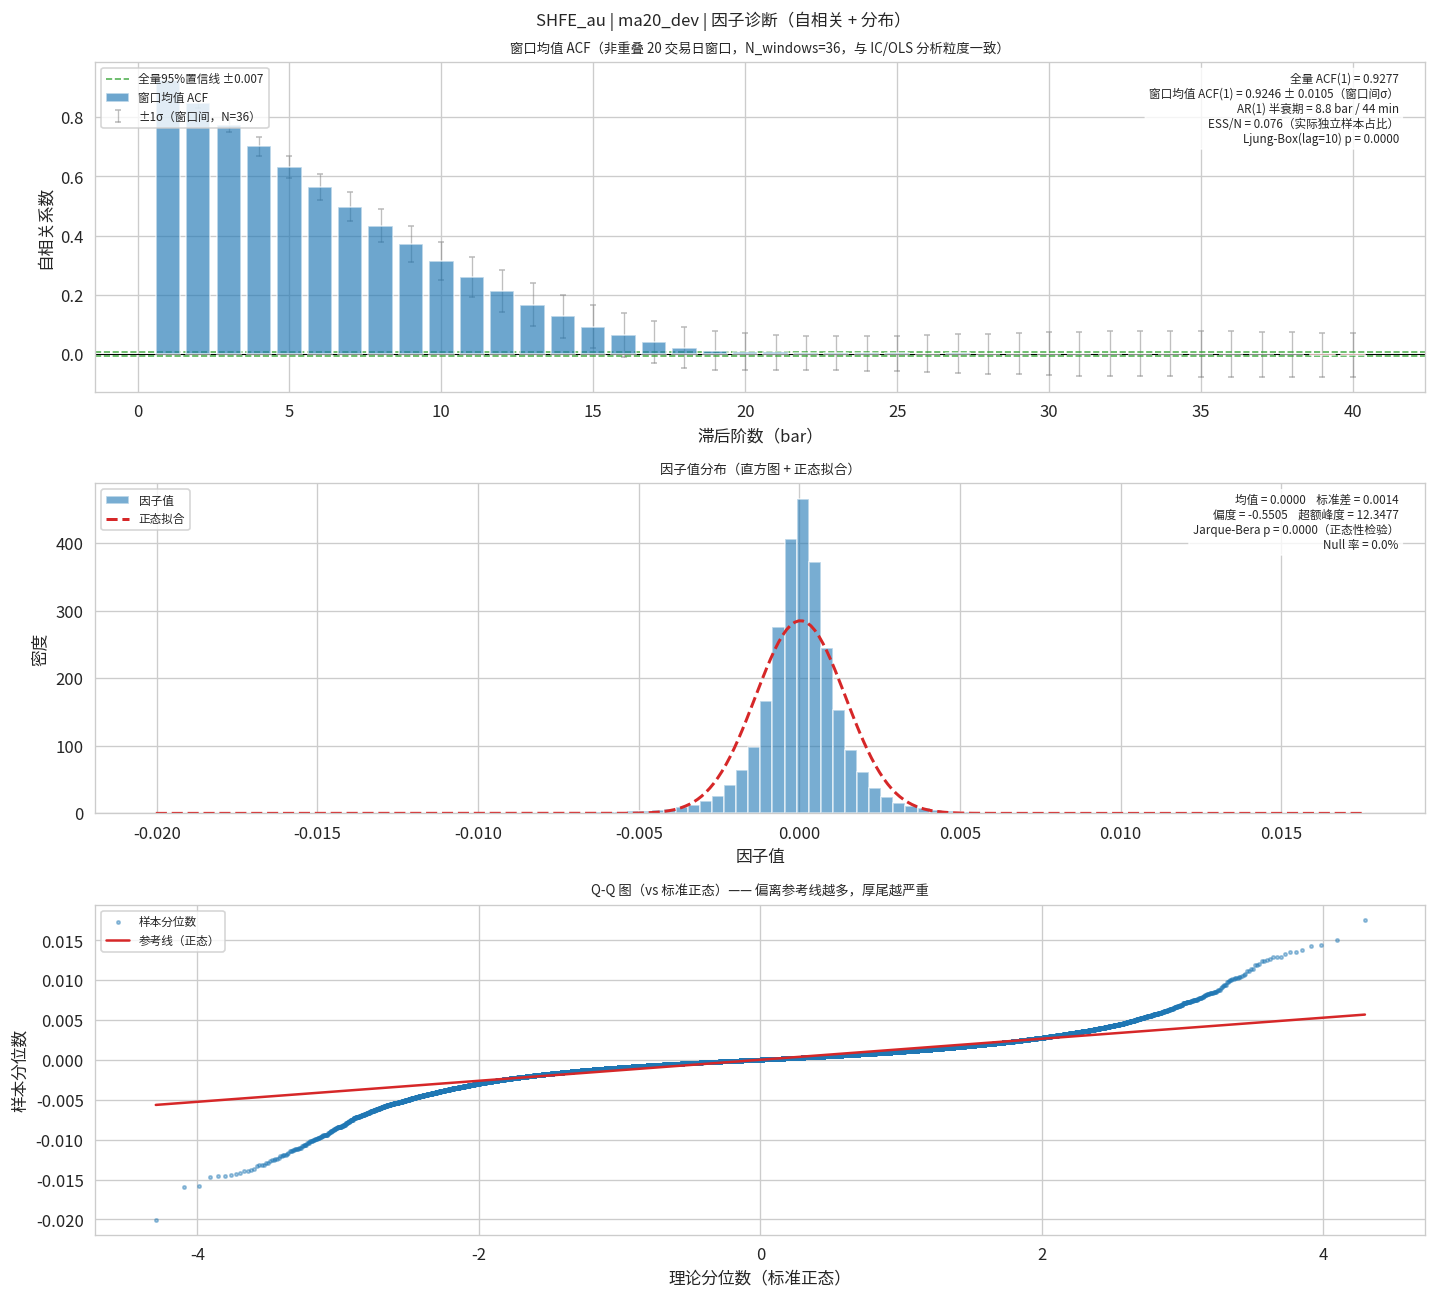

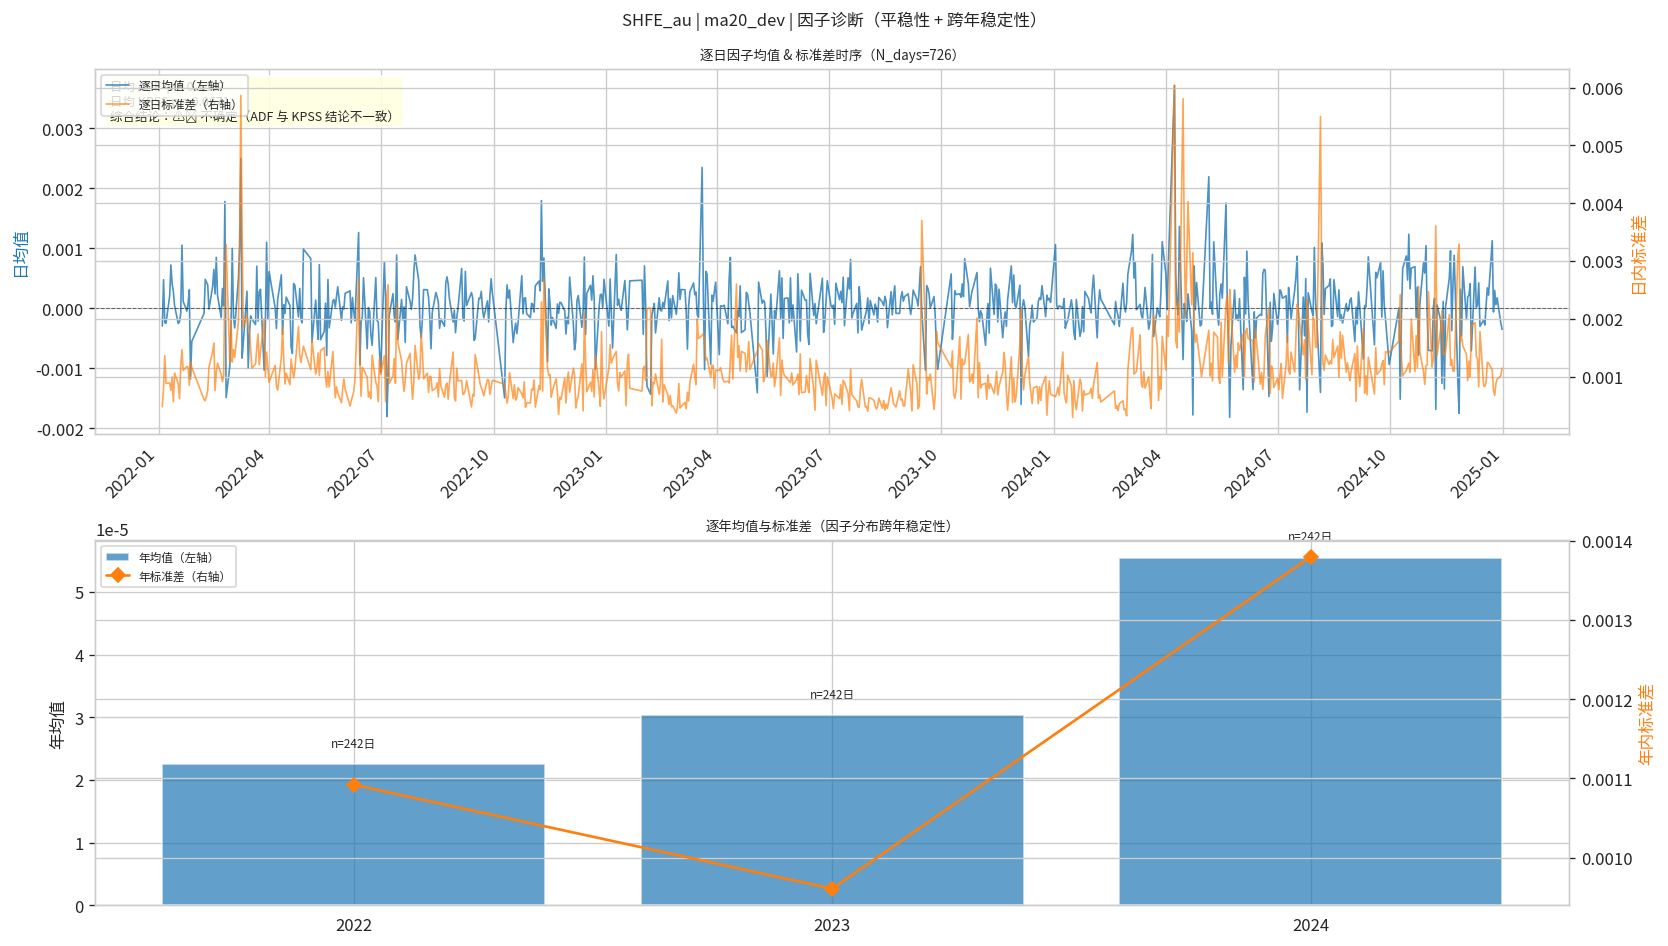

窗口均值 ACF(1) = 0.9246  （36 个非重叠窗口 × 20 交易日）
AR(1) 半衰期    = 8.8 bar / 44 min
ESS/N           = 0.076  （有效独立样本占比，越低自相关越强）
JB p 值         = 0.0000  （< 0.05 → 显著非正态）
平稳性结论      = ⚠️ 不确定（ADF 与 KPSS 结论不一致）


{'factor': 'ma20_dev',
 'acf_lags': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40],
 'acf_win_mean': [0.9245768337710358,
  0.8490270956169232,
  0.7751421546467369,
  0.7022500667324019,
  0.6320120690746,
  0.5641170513100767,
  0.49822617493711274,
  0.4340014616273458,
  0.37214870067220174,
  0.31536000400299385,
  0.26193978707976195,
  0.21267087586893807,
  0.16801434710120722,
  0.1285023368976437,
  0.09354491553050304,
  0.06455112684889573,
  0.04093952482029041,
  0.022928101790928936,
  0.012341274208932896,
  0.00924231409819276,
  0.006794257767203582,
  0.005357516415991922,
  0.003669570409939698,
  0.0033529627633223725,
  0.0029031718728779236,
  0.0025727502065826307,
  0.003040752148190886,
  0.0023316662954609066,
  0.002277461680027051,
  0.002249787915256567,
  0.001640844760222590

In [6]:
# ── 因子诊断 ──────────────────────────────────────────────────────
# max_lags：ACF 最大滞后阶数，默认 40 棒（200 分钟）
# 输出：2 张图（自相关+分布图、平稳性+跨年图）+ 返回值字典
prop_stats = lab.properties_only(my_factor, name='ma20_dev', max_lags=40)

# 关键指标摘要打印
if prop_stats:
    acf1 = prop_stats.get('acf1_win_mean',    float('nan'))
    hl   = prop_stats.get('half_life_bars',    float('nan'))
    ess  = prop_stats.get('ess_ratio',         float('nan'))
    jbp  = prop_stats.get('jb_p',              float('nan'))
    stat = prop_stats.get('stationarity',      'N/A')
    nwin = prop_stats.get('n_windows_acf',     0)
    wday = prop_stats.get('window_days',       20)
    hl_str = f'{hl:.1f} bar / {hl * 5:.0f} min' if hl == hl else 'N/A'
    print(f'窗口均值 ACF(1) = {acf1:.4f}  （{nwin} 个非重叠窗口 × {wday} 交易日）')
    print(f'AR(1) 半衰期    = {hl_str}')
    print(f'ESS/N           = {ess:.3f}  （有效独立样本占比，越低自相关越强）')
    print(f'JB p 值         = {jbp:.4f}  （< 0.05 → 显著非正态）')
    print(f'平稳性结论      = {stat}')
prop_stats

---
## 分位分析（`quantile_only`）

**方法**：使用 Polars `rolling_quantile` 向量化计算因子值的滚动分位数边界（无未来信息），
将每根 bar 分配到 Q1~Qn 层（Q1 最低，Qn 最高），预热期自动丢弃。

分析两个维度：

**维度一（单调性）**：全样本各层均值收益柱状图 + 箱线图，
输出 Spearman 单调性系数（`monotone_r`）和多空价差（`ls_spread`）。
`monotone_r = +1` 表示完美单调递增，即因子值越高收益越高。

**维度二（时段效应）**：通过 `session_template` 将 bar 映射到品种的交易时段，
输出「时段 × 分层」均值收益热力图，识别因子在哪些时段有效、哪些时段失效。

**`session_template` 内置模板**：

| 模板名 | 适用品种 |
|--------|---------|
| `day_only` | 无夜盘品种（部分农产品） |
| `night_2300` | 黑色系（j / i / SA / FG 等） |
| `night_0100` | 有色金属（cu / al 等） |
| `night_0230` | 贵金属（au / ag） |
| `stock_index` | 股指期货（IF / IC / IH / IM） |
| `bond` | 国债期货（T / TF / TS / TL） |

**输出指标**：

| 指标 | 含义 |
|------|------|
| `monotone_r` | 各层均值与层编号的 Spearman 相关，衡量单调性 |
| `ls_spread` | Qn 层均值 - Q1 层均值，多空价差 |

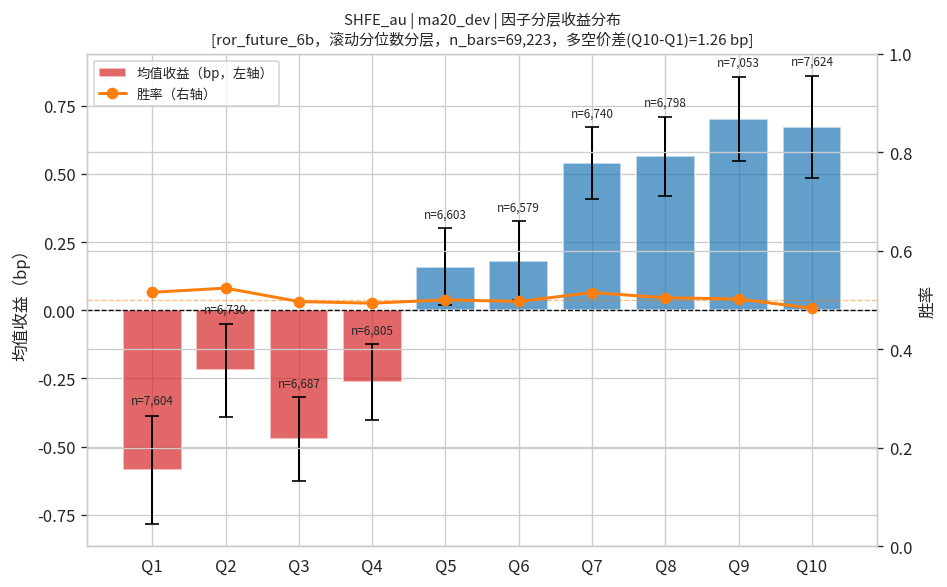

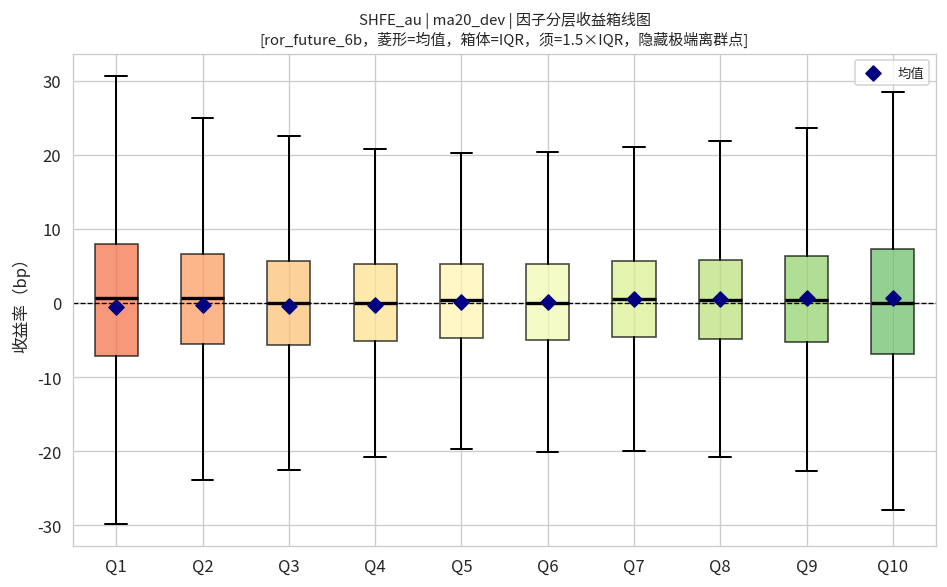

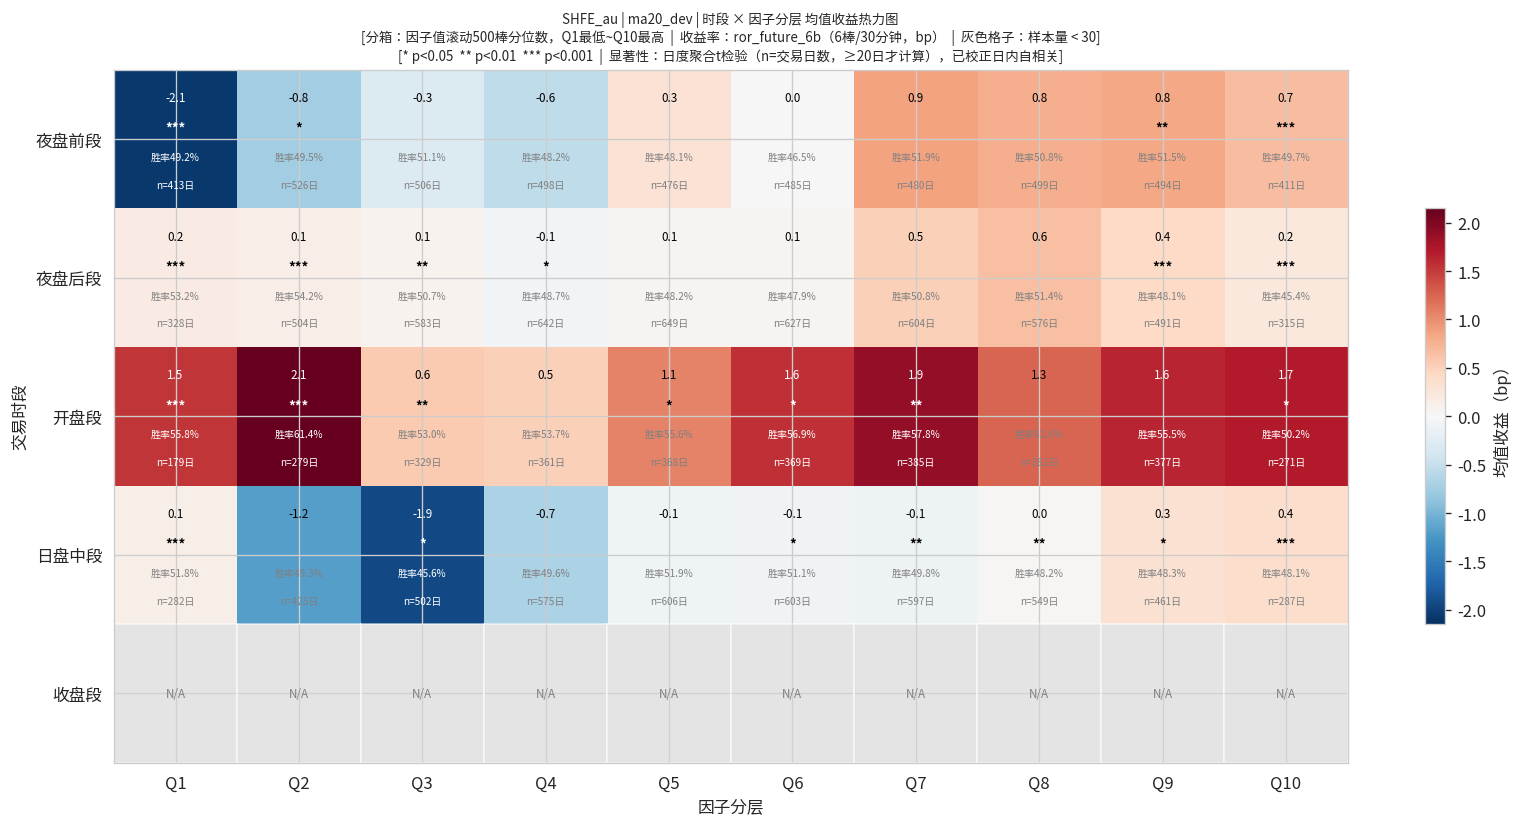

{'factor': 'ma20_dev',
 'n_quantiles': 10,
 'rolling_window': 500,
 'n_bars_analyzed': 69223,
 'ror_col': 'ror_future_6b',
 'use_bp': True,
 'ls_spread': 1.2556,
 'ls_spread_unit': 'bp',
 'monotone_r': 0.9515,
 'quantile_stats': [{'layer': 1,
   'label': 'Q1',
   'n_bars': 7604,
   'mean': -0.5850815967602445,
   'median': 0.6468515831847821,
   'std': 17.293623116345703,
   'win_rate': 0.5159126775381379,
   'skew': -1.3155800965461615,
   'kurt': 8.687444028279069,
   'q10': -18.62903169883423,
   'q25': -7.14903643153103,
   'q75': 8.004768962558417,
   'q90': 16.500764128785537},
  {'layer': 2,
   'label': 'Q2',
   'n_bars': 6730,
   'mean': -0.22015560070872317,
   'median': 0.6785755693028417,
   'std': 13.895300453235578,
   'win_rate': 0.524368499257058,
   'skew': -2.125437401535675,
   'kurt': 18.721366161189678,
   'q10': -13.805982372193991,
   'q25': -5.586264902158189,
   'q75': 6.6175272848034705,
   'q90': 13.314606285566022},
  {'layer': 3,
   'label': 'Q3',
   'n_bars

In [7]:
# ── 分位分析 ──────────────────────────────────────────────────────
# session_template 控制时段热力图的时段划分
# 内置模板：'day_only' / 'night_2300' / 'night_0100' / 'night_0230' / 'stock_index' / 'bond'
qa_stats = lab.quantile_only(
    my_factor,
    n_quantiles=10,
    name='ma20_dev',
    #session_template='night_0230',   # 修改为目标品种对应的模板
    #session_template='night_2300'
)
qa_stats

---
## Horizon 分析（`horizon_only`）

**方法**：将因子值按滚动分位数分为 Q1~Qn 层，对每个持仓期 h（5、10、…、60分钟），
统计各层的均值收益率（bp）、胜率和显著性，观察因子预测能力随持仓期的演化。

回答的核心问题：**持有多长时间，因子的分层信号最有效？**

**两张图表：**
- **上图**：Q1~Qn 各层均值收益折线（bp），带 ±1 SE 误差带和各点显著性星号
- **下图**：多空价差 (Qn-Q1) 柱状图，显著性基于 **Welch 双样本独立 t 检验**

**显著性检验：**
- `correct_autocorr=True`（默认）：日度聚合 t 检验，已校正日内自相关；多空价差用双样本 Welch t 检验，直接检验"Q_n 日均值 ≠ Q_1 日均值"
- `correct_autocorr=False`：朴素 t 检验（未校正），p 值偏低，显著性可能虚高

**`horizons` 参数：**
- `None`（默认）→ 自动从 `infra_df` 检测所有可用的 `ror_future_Nb` 列；覆盖范围由 `FeatureEngineer(horizon_bars=...)` 控制，默认 1~12 bar（5~60 分钟）
- 也可显式指定子集，如 `horizons=[1, 2, 3, 6, 12]`，只分析指定的持仓期

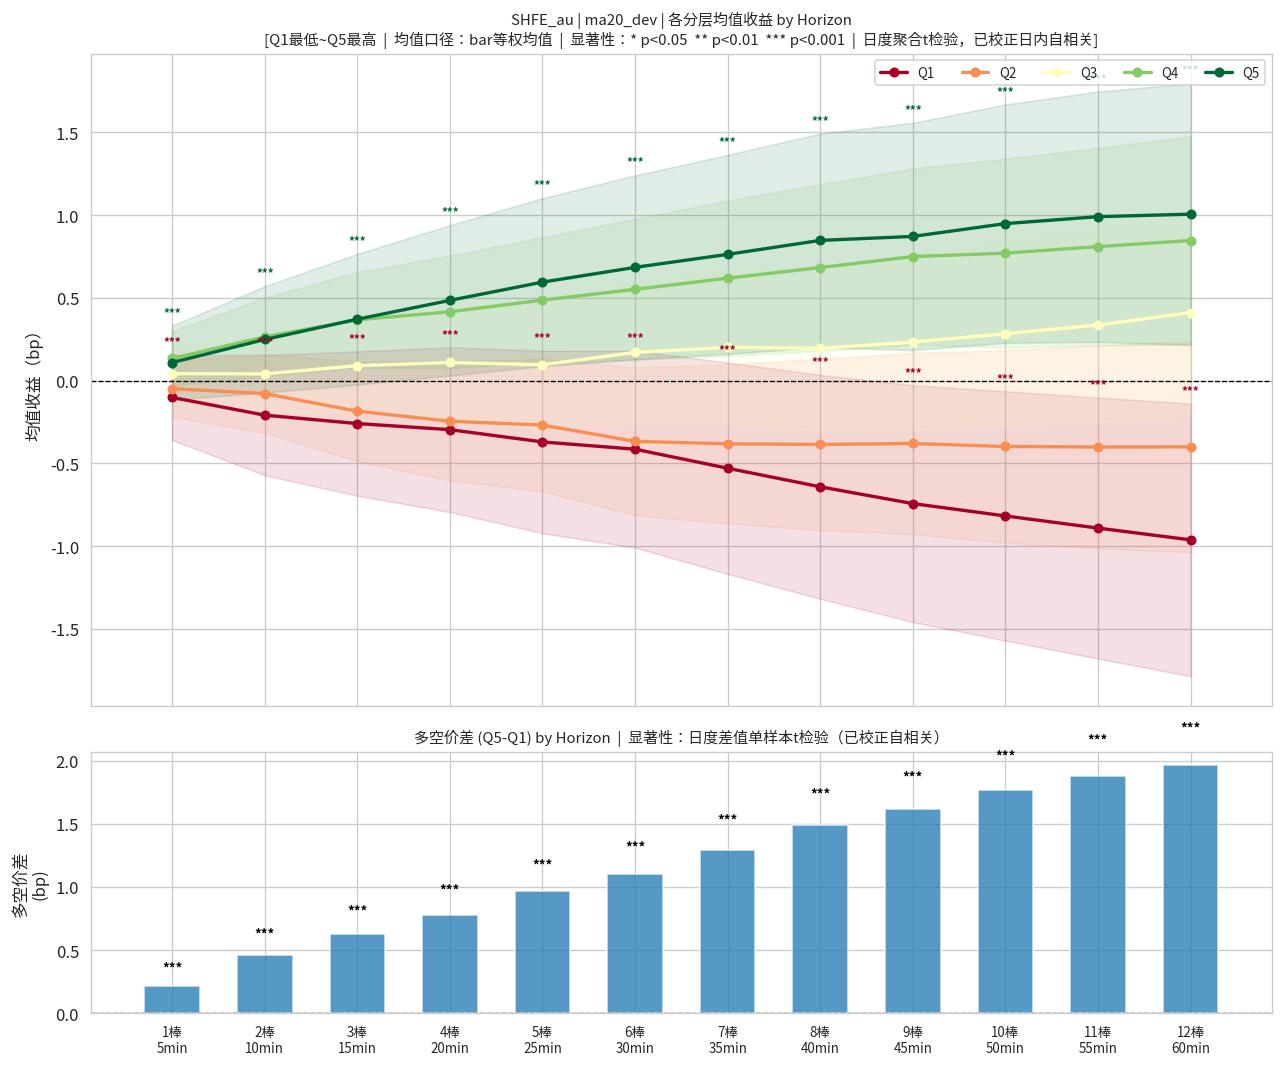

可用 Horizon：[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] bar（[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60] 分钟）
多空价差绝对值最大 Horizon：12 bar = 60 分钟

     Horizon      多空价差(bp)     Welch-p     显著性
------------------------------------------------
   1棒/  5min     +0.21      0.0000  ***
   2棒/ 10min     +0.46      0.0000  ***
   3棒/ 15min     +0.63      0.0000  ***
   4棒/ 20min     +0.78      0.0000  ***
   5棒/ 25min     +0.97      0.0000  ***
   6棒/ 30min     +1.10      0.0000  ***
   7棒/ 35min     +1.29      0.0000  ***
   8棒/ 40min     +1.49      0.0000  ***
   9棒/ 45min     +1.61      0.0000  ***
  10棒/ 50min     +1.77      0.0000  ***
  11棒/ 55min     +1.88      0.0000  ***
  12棒/ 60min     +1.97      0.0000  ***


In [8]:
# ── Horizon 分析 ───────────────────────────────────────────────
# horizons=None → 自动检测所有可用持仓期（由 FeatureEngineer.horizon_bars 决定）
# 也可显式指定子集，如 horizons=list(range(1, 13)) 或 horizons=[1,2,3,6,12]
hz_stats = lab.horizon_only(
    my_factor,
    name='ma20_dev',
    n_quantiles=5,
    correct_autocorr=True,     # 日度聚合 t 检验，已校正日内自相关
)

# 返回值摘要
if hz_stats:
    peak_h   = hz_stats.get('peak_ls_horizon_bars')
    peak_min = hz_stats.get('peak_ls_horizon_min')
    print(f"可用 Horizon：{hz_stats['horizons']} bar（{hz_stats['minutes']} 分钟）")
    print(f"多空价差绝对值最大 Horizon：{peak_h} bar = {peak_min} 分钟")
    print(f"\n{'Horizon':>12}  {'多空价差(bp)':>12}  {'Welch-p':>10}  {'显著性':>6}")
    print("-" * 48)
    for h in hz_stats['horizons']:
        sp = hz_stats['ls_spread'].get(h, float('nan'))
        pv = hz_stats['ls_p_value'].get(h, float('nan'))
        stars = ('***' if pv < 0.001 else '**' if pv < 0.01
                 else '*' if pv < 0.05 else '') if pv == pv else ''
        sp_str = f'{sp:+8.2f}' if sp == sp else '     N/A'
        pv_str = f'{pv:.4f}'   if pv == pv else '     N/A'
        print(f"  {h:2d}棒/{h*5:3d}min  {sp_str}      {pv_str}  {stars}")

---
## 累计收益曲线（`cumreturn_only`）

**方法**：将因子值按滚动分位数分为 Q1~Qn 层，对每个交易日分别计算 Q5 层和 Q1 层的 `ror_future_hb` 均值（日度聚合），然后进行**单利累加**，得到各层的累计收益曲线。

以**基点（bp）**为单位，避免对极小收益值的误读，也有助于保守评估因子能力。

**两张图表：**
- **上图**：Q5（多头）、Q1（空头取负）、Q5-Q1（多空组合）三条累计收益曲线，附年份边界线和多空组合的回撤填充区域
- **下图**：逐年收益贡献柱状图，直观看因子在各年的有效性

**关键指标：**

| 指标 | 定义 |
|------|------|
| 总计累计收益 | `sum(Q5日均值 - Q1日均值)` 的全期总和（bp）|
| 最大回撤 | 多空累计曲线峰值到谷值的最大降幅（bp，单利定义）|
| 年化 Sharpe | `mean(Q5日均值 - Q1日均值) / std(...) × √252`，与累积方式无关 |

**`horizon` 参数：**
- `None`（默认）→ 自动使用 `label_bars`（与其他分析模块保持一致）
- 也可显式指定，如 `horizon=3`（15分钟持仓）

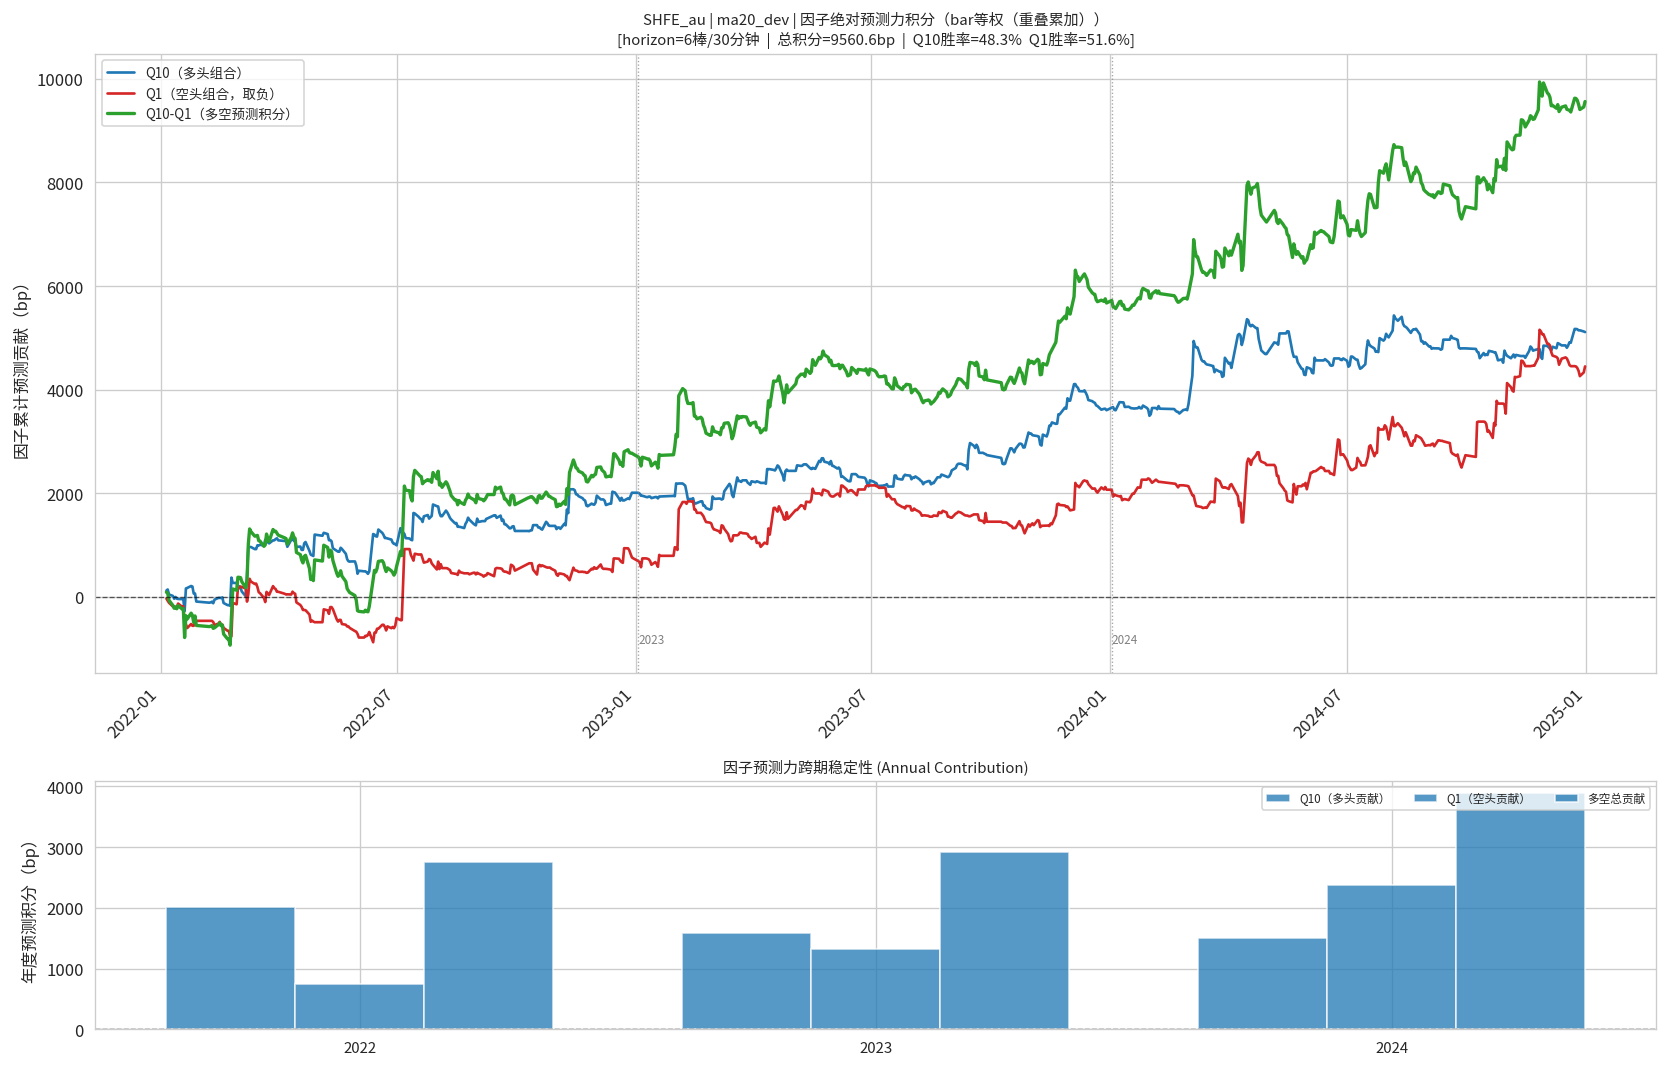

In [9]:
# ── 累计收益曲线 ──────────────────────────────────────────────
# horizon=None → 自动使用 label_bars（与 ic_only/quantile_only 一致）
# 也可显式指定，如 horizon=3（15分钟持仓）
cr_stats = lab.cumreturn_only(
    my_factor,
    name='ma20_dev',
    horizon=None,
    n_quantiles=10,
    use_daily_mean=False
)

---
## 单因子回测（`backtest_only`）

**方法**：基于持仓状态机，使用滚动分位数动态阈值产生做多/做空信号，在严格无未来信息的条件下模拟真实 CTA 回测逻辑。

**核心规则**：

| 条件 | 行为 |
|---|---|
| 空仓 + 有信号（factor > 上分位数 → 多，factor < 下分位数 → 空） | 下一根 bar 开盘开仓，扣单边成本 |
| 持仓 + 相同方向信号 | 持仓不动 |
| 持仓 + 反向信号 | 下一根 bar 开盘反手（平旧开新），扣2倍单边成本 |
| 持仓满 `label_bars` 根到期，恰有新信号 | 同价平旧开新（续仓或反手），扣2倍单边成本 |
| 持仓满 `label_bars` 根到期，无有效信号 | 平仓，扣单边成本 |
| 靠近 session 末（`ror_future_Nb` 为 null） | 禁止新开仓，自然平仓 |

**成本计算**：`单边成本 = slippage_ticks × tick_size / 入场价`，开仓和平仓各扣一次（往返共2倍）。

**两条净值曲线**：每个阈值对同时输出 cost=0（毛收益，虚线）和 with cost（净收益，实线）曲线，直观显示成本侵蚀程度。支持多阈值并行对比。

**关键指标**：

| 指标 | 说明 |
|---|---|
| `annual_net_bp` | 年化净收益（bp/年），基于每日净收益均值 × 252 |
| `sharpe_net` | 年化 Sharpe = mean(日净收益) / std(日净收益) × √252 |
| `max_dd_net_bp` | 最大回撤深度（bp），基于累计净值曲线的最大水下深度 |
| `win_rate_net` | 逐笔胜率（净收益 > 0 的笔数占比） |
| `profit_factor_net` | 盈亏比 = 平均盈利 / 平均亏损（绝对值） |
| `n_trades` | 总交易笔数（多头 + 空头） |

> **与 `cumreturn_only` 的区别**：`cumreturn_only` 是每日分层均值的无摩擦积分（"预测力积分"），不含任何交易规则。`backtest_only` 是持仓状态机回测，含反手/续仓/成本逻辑，更接近实盘可落地的资金曲线。


In [ ]:
# ── 单因子回测 ──────────────────────────────────────────────────────
# thresholds：多阈值对列表，每对 (lo_q, hi_q) 独立运行状态机
#   factor < 下分位数（lo_q）→ 做空信号；factor > 上分位数（hi_q）→ 做多信号
#   None → 自动从 config backtest.thresholds 读取
# rolling_window：滚动分位数回望窗口（bar数），None → 读 config
# slippage_ticks：单边滑点（跳数），None → 读 config backtest.slippage_ticks

bt_stats = lab.backtest_only(
    my_factor,
    name='ma20_dev',
    thresholds=[(0.2, 0.8), (0.25, 0.75), (0.3, 0.7)],   # 可改为 None 用 config 默认值
    rolling_window=500,
    slippage_ticks=1.5,
)

# 关键指标摘要打印
if bt_stats:
    print(f"最优阈值       : {bt_stats['best_threshold']}")
    print(f"年化净收益     : {bt_stats['best_annual_net_bp']:.1f} bp/年")
    print(f"Sharpe(净)     : {bt_stats['best_sharpe_net']:.3f}")
    print(f"最大回撤(净)   : {bt_stats['best_max_dd_net_bp']:.1f} bp")
    print()
    # 全阈值对比
    for thr, m in bt_stats['all_metrics'].items():
        print(f"  阈值 {thr[0]:.0%}/{thr[1]:.0%}:")
        print(f"    Sharpe  cost=0={m['sharpe_raw']:.3f}  with_cost={m['sharpe_net']:.3f}")
        print(f"    总笔数={m['n_trades']}  多头={m['n_long']}  空头={m['n_short']}")
        print(f"    胜率={m['win_rate_net']:.1%}  盈亏比={m.get('profit_factor_net','N/A')}")


---
## 其他功能

### `lab.check_leakage()` — 数据泄漏检测

在原始 `bar1min` 中选定一个注入点，将该点之后的数据施加大幅扰动（OHLC + delta、
volume × 2、OI × 2），对比注入前后注入点**之前**的因子值是否发生变化。
有任何差异即说明因子计算存在未来信息泄漏：

```python
result = lab.check_leakage(
    my_factor,
    name='ma20_dev',
    inject_idx=None,     # None = 自动选择数据集中间位置
    inject_delta=1e9,    # 注入扰动量，足够大以捕获任何轻微泄漏
    check_bars=True,     # 同时检查多周期K线
    verbose=True,
)
print('是否泄漏:', result['leaked'])
```

### 多品种对比

对同一因子在多个品种上分别初始化 `FactorLab` 进行评估：

```python
SYMBOLS = ['SHFE_au', 'SHFE_ag', 'SHFE_cu']
results = {}
for sym in SYMBOLS:
    _lab = FactorLab(sym, config_path=CONFIG)
    ic   = _lab.ic_only(my_factor, name='ma20_dev')
    results[sym] = {
        'icir':   ic.get('main_icir',    float('nan')),
        't_stat': ic.get('main_t_stat',  float('nan')),
        'win_rate': ic.get('main_win_rate', float('nan')),
    }

import polars as pl
print(pl.DataFrame([{'symbol': k, **v} for k, v in results.items()]))
```

In [10]:
# 似乎黄金早盘做多有非零收益
import scipy.stats as stats
ror6 = lab._infra_df['ror_future_6b'].to_numpy()
ror6_open = lab._infra_df.filter(pl.col('datetime').dt.time().is_between(pl.time(9, 0), pl.time(10, 00)))['ror_future_6b'].to_numpy()
r1 = np.nanmean(ror6_open) * 10000
r2 = np.nanmean(ror6) * 10000
print(f'早盘（9:00 - 10:00）ror6: {r1:.2f} bp, 全部时间：ror6: {r2:.2f} bp')

nan_mask1 = np.isfinite(ror6_open)
nan_mask2 = np.isfinite(ror6)
r1_f = ror6_open[nan_mask1]
r2_f = ror6[nan_mask2]
t1 = stats.ttest_1samp(r1_f, 0)
t2 = stats.ttest_1samp(r2_f, 0)
print(t1, t2)

早盘（9:00 - 10:00）ror6: 1.34 bp, 全部时间：ror6: 0.12 bp
TtestResult(statistic=np.float64(11.757681479253845), pvalue=np.float64(9.447751721374007e-32), df=np.int64(12596)) TtestResult(statistic=np.float64(2.656879558887928), pvalue=np.float64(0.007888116703287104), df=np.int64(92399))


(array([ 11.,  15.,   8.,   6.,  10.,  12.,  23.,  12.,  24.,  18.,  15.,
         24.,  19.,  27.,  28.,  26.,  29.,  28.,  34.,  45.,  34.,  42.,
         36.,  46.,  75.,  75.,  68.,  79.,  96., 111., 102., 127., 130.,
        123., 139., 150., 189., 196., 181., 220., 208., 275., 250., 256.,
        286., 334., 382., 323., 361., 238., 375., 381., 379., 367., 288.,
        292., 329., 302., 306., 309., 269., 240., 228., 231., 206., 176.,
        168., 146., 160., 124., 133., 121.,  99.,  77.,  98.,  84.,  75.,
         77.,  45.,  52.,  51.,  44.,  59.,  44.,  42.,  30.,  26.,  27.,
         33.,  27.,  19.,  18.,  23.,  23.,  18.,  16.,  20.,  12.,  15.]),
 array([-3.00000000e-03, -2.93939394e-03, -2.87878788e-03, -2.81818182e-03,
        -2.75757576e-03, -2.69696970e-03, -2.63636364e-03, -2.57575758e-03,
        -2.51515152e-03, -2.45454545e-03, -2.39393939e-03, -2.33333333e-03,
        -2.27272727e-03, -2.21212121e-03, -2.15151515e-03, -2.09090909e-03,
        -2.03030303e-03, -1.

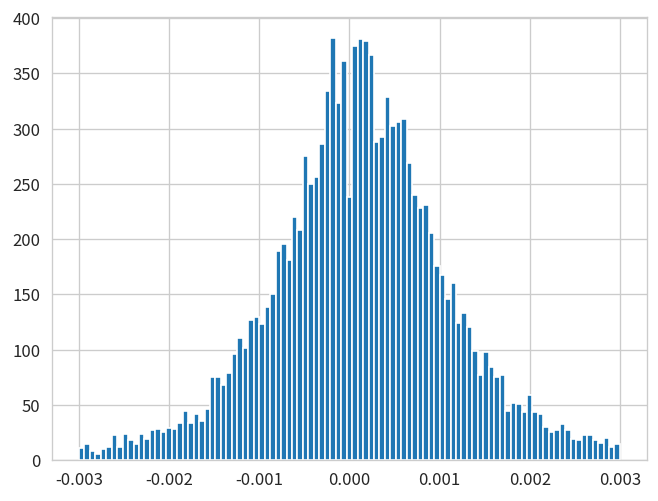

In [11]:
plt.hist(r1_f, bins = np.linspace(-0.003, 0.003, 100))